In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from sklearn.metrics import r2_score

import wandb

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda:0


In [3]:
DATA_ROOT = './data/models'
RAW_DIR = os.path.join(DATA_ROOT, 'raw')

df = pd.read_csv(os.path.join(RAW_DIR, 'combined_dataset.csv'), index_col='SEQID')
df.sort_index(inplace=True)


# the dataset splits is in a .json file
with open(os.path.join(RAW_DIR, 'combined_data_split.json'), 'r') as f:
    split_dict = json.load(f)
# z

# print(f"Split_dic is {split_dict}")
df.head(2)

,dataset,RefSeq,TargetStruct,sodium,DNA_conc,dH,Tm,dG_37
SEQID,,,,,,,,
BC1,arr,CAACCAGAAATGGTTG,((((((....)))))),0.063,NaN,-29.405457,52.382626,-1.389517
BC10,arr,CAATCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-13.860604,28.607763,0.385480


In [4]:
def calc_sumstats(df):
    return {
        'dH_min': np.min(df.dH), 'dH_max': np.max(df.dH),
        'Tm_min': np.min(df.Tm), 'Tm_max': np.max(df.Tm)
    }

def normalize(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin)

def unnormalize(val, vmin, vmax):
    return val * (vmax - vmin) + vmin

def calc_dG37(dH, Tm):
    """Calculate dG at 37°C from dH (kcal/mol) and Tm (°C)."""
    return dH * (1 - (273.15 + 37) / (273.15 + Tm))

# Compute stats from training split only
train_df = df.loc[df.index.isin(split_dict['train_ind'])]
stats = calc_sumstats(train_df)
print('Training set normalization stats:')
print(stats)

Training set normalization stats:
{'dH_min': -68.20454632608892, 'dH_max': -2.70243642577065, 'Tm_min': 13.647488646379209, 'Tm_max': 68.63588396988382}


In [4]:
data_ = ['arr', 'ov', 'lit_uv', 'uv']
range_analysis ={'name':[], 'range': []}
min_max_analysis = {}
for data in data_:
    df_data = df[df['dataset'] == data]
    range_min = calc_sumstats(df_data)
    range_analysis['name'].append(data)
    range_analysis['range'].append([range_min[value] for key, value in enumerate(range_min)])
for i in range(4):
    print(f"the range of {range_analysis['name'][i]}, dhmin: {range_analysis['range'][i][0]}, dhmax{range_analysis['range'][i][1]}, Tmmin{range_analysis['range'][i][2]}, tmmax{range_analysis['range'][i][3]}")
    # range_analysis['range'][i][1]

the range of arr, dhmin: -68.20454632608892, dhmax-2.70243642577065, Tmmin13.647488646379209, tmmax68.63588396988382
the range of ov, dhmin: nan, dhmaxnan, Tmmin41.6, tmmax69.3
the range of lit_uv, dhmin: nan, dhmaxnan, Tmmin39.1, tmmax88.6
the range of uv, dhmin: -56.82647626729113, dhmax-23.04809725871276, Tmmin28.323514251703312, tmmax71.0105241938826


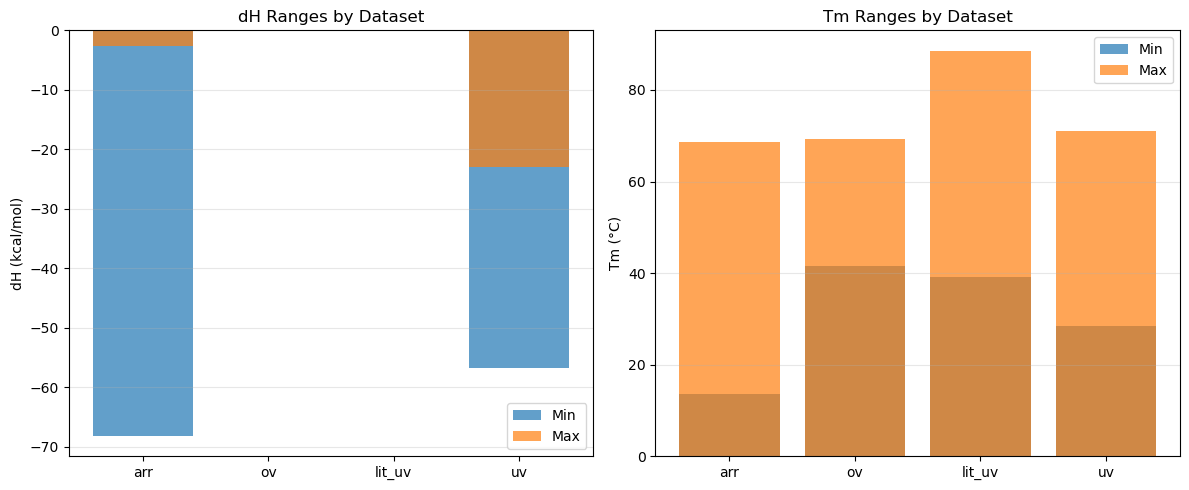

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot dH ranges
dH_mins = [range_analysis['range'][i][0] for i in range(4)]
dH_maxs = [range_analysis['range'][i][1] for i in range(4)]
axes[0].bar(range_analysis['name'], dH_mins, label='Min', alpha=0.7)
axes[0].bar(range_analysis['name'], dH_maxs, label='Max', alpha=0.7)
axes[0].set_ylabel('dH (kcal/mol)')
axes[0].set_title('dH Ranges by Dataset')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot Tm ranges
Tm_mins = [range_analysis['range'][i][2] for i in range(4)]
Tm_maxs = [range_analysis['range'][i][3] for i in range(4)]
axes[1].bar(range_analysis['name'], Tm_mins, label='Min', alpha=0.7)
axes[1].bar(range_analysis['name'], Tm_maxs, label='Max', alpha=0.7)
axes[1].set_ylabel('Tm (°C)')
axes[1].set_title('Tm Ranges by Dataset')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2D "Folded Ladder" Encoding

**Key idea:** Fold the hairpin at the loop midpoint to create a physically meaningful 2D image:
- **Row 0 (top strand):** 5' stem + left half of loop  
- **Row 1 (H-bond):** 1 = base-paired, 0 = loop  
- **Row 2 (bottom strand):** 3' stem reversed + right half of loop reversed  
- **Last column:** backbone turn marker (present for hairpins, absent for duplexes)

**One-hot channels** (avoid false ordinal relationships):

| Channel | Meaning |
|---------|---------|
| 0 | is_A |
| 1 | is_T |
| 2 | is_G |
| 3 | is_C |
| 4 | is_paired (H-bond row) |
| 5 | is_backbone_turn |

Final tensor shape: **(6, 3, max_width)** — a 6-channel, 3-pixel tall, W-pixel wide image.

A **Conv2d kernel of size (3, k)** spans both strands + H-bond info at k consecutive positions — directly capturing nearest-neighbor stacking interactions.

In [5]:
# ---- 2D Encoding: Fold hairpin into ladder representation ----

MAX_WIDTH = 15  # ceil(24/2) + 1 backbone column; covers all arr sequences (11-24 nt)
NT_MAP = {'A': 0, 'T': 1, 'G': 2, 'C': 3}


def encode_2d_hairpin(seq, struct, max_width=MAX_WIDTH):
    """
    Fold a hairpin into a 2D 'ladder' representation with one-hot encoding.
    
    The hairpin is folded at the loop midpoint:
      Row 0: 5' stem + left half of loop   (top strand)
      Row 1: H-bond indicator              (1=paired, 0=loop)
      Row 2: 3' stem reversed + right half (bottom strand)
      Last col: backbone turn marker
    
    Args:
        seq: DNA sequence string (e.g. 'CAACCAGAAATGGTTG')
        struct: dot-bracket string (e.g. '((((((....)))))))' )
        max_width: pad to this width
    
    Returns:
        (6, 3, max_width) float32 numpy array
        Channels: [is_A, is_T, is_G, is_C, is_paired, is_backbone]
    """
    # Count stem and loop
    n_stem = struct.count('(')
    n_loop = struct.count('.')
    half_loop = n_loop // 2
    has_middle = (n_loop % 2 == 1)
    
    # Split sequence at fold point
    fold_len = n_stem + half_loop   # length of each strand half
    
    top_seq = seq[:fold_len]
    if has_middle:
        middle_nt = seq[fold_len]
        bottom_seq = seq[fold_len + 1:][::-1]
    else:
        middle_nt = None
        bottom_seq = seq[fold_len:][::-1]
    
    # H-bond pattern: 1 for stem positions, 0 for loop positions
    hbond = [1.0] * n_stem + [0.0] * half_loop
    
    # Build tensor: (6 channels, 3 rows, max_width)
    tensor = np.zeros((6, 3, max_width), dtype=np.float32)
    
    # Fill top strand (row 0) — one-hot nucleotides
    for i, nt in enumerate(top_seq):
        tensor[NT_MAP[nt.upper()], 0, i] = 1.0
    
    # Fill bottom strand (row 2) — one-hot nucleotides
    for i, nt in enumerate(bottom_seq):
        tensor[NT_MAP[nt.upper()], 2, i] = 1.0
    
    # Fill H-bond row (row 1, channel 4)
    for i, h in enumerate(hbond):
        tensor[4, 1, i] = h
    
    # Backbone turn column (at position fold_len)
    bb_col = fold_len
    tensor[5, 0, bb_col] = 1.0   # top backbone
    tensor[5, 1, bb_col] = 1.0   # middle backbone
    tensor[5, 2, bb_col] = 1.0   # bottom backbone
    
    # If odd loop: embed the middle nucleotide in the backbone column (row 1)
    if has_middle and middle_nt:
        tensor[NT_MAP[middle_nt.upper()], 1, bb_col] = 1.0
    
    return tensor


def encode_2d_duplex(strand1, strand2, struct, max_width=MAX_WIDTH):
    """
    Encode a duplex (two strands) into the same 2D ladder format.
    No backbone turn column — this is how the model distinguishes hairpin vs duplex.
    
    Args:
        strand1, strand2: DNA sequence strings
        struct: dot-bracket with '+' separator
        max_width: pad to this width
    
    Returns:
        (6, 3, max_width) float32 numpy array
    """
    tensor = np.zeros((6, 3, max_width), dtype=np.float32)
    
    # Top strand = strand1 (5'→3')
    for i, nt in enumerate(strand1):
        if i < max_width:
            tensor[NT_MAP[nt.upper()], 0, i] = 1.0
    
    # Bottom strand = strand2 reversed (to align base pairs)
    rev_strand2 = strand2[::-1]
    for i, nt in enumerate(rev_strand2):
        if i < max_width:
            tensor[NT_MAP[nt.upper()], 2, i] = 1.0
    
    # H-bond: all paired for perfect duplexes
    n_pairs = min(len(strand1), max_width)
    for i in range(n_pairs):
        tensor[4, 1, i] = 1.0
    
    # No backbone column — that's the structural signal!
    
    return tensor


def encode_row_2d(row, stats, max_width=MAX_WIDTH):
    """
    Encode a single dataframe row into the 2D folded representation.
    Handles both hairpins and duplexes.
    
    Returns:
        x: (6, 3, max_width) tensor
        y: (2,) tensor — normalized [dH, Tm]
    """
    refseq = row['RefSeq']
    struct = row['TargetStruct']
    
    if '+' in struct:
        # Duplex: parse the two strands
        if isinstance(refseq, str) and '[' in refseq:
            strands = eval(refseq)
        elif isinstance(refseq, list):
            strands = refseq
        else:
            # Split sequence at the + position
            plus_pos = struct.index('+')
            strands = [refseq[:plus_pos], refseq[plus_pos+1:]]
        
        arr = encode_2d_duplex(strands[0], strands[1], struct, max_width)
    else:
        # Hairpin
        arr = encode_2d_hairpin(refseq, struct, max_width)
    
    x = torch.tensor(arr, dtype=torch.float)
    
    # Normalize targets
    dH_norm = normalize(row.dH, stats['dH_min'], stats['dH_max'])
    Tm_norm = normalize(row.Tm, stats['Tm_min'], stats['Tm_max'])
    y = torch.tensor([dH_norm, Tm_norm], dtype=torch.float)
    
    return x, y


# Quick test
sample = df.iloc[0]
print(f"Sequence: {sample['RefSeq']}")
print(f"Structure: {sample['TargetStruct']}")
x_test, y_test = encode_row_2d(sample, stats)
print(f"\nEncoded shape: {x_test.shape}  (6 channels × 3 rows × {MAX_WIDTH} width)")
print(f"Target (normalized): {y_test}")
print(f"\nChannel names: [is_A, is_T, is_G, is_C, is_paired, is_backbone]")

Sequence: CAACCAGAAATGGTTG
Structure: ((((((....))))))

Encoded shape: torch.Size([6, 3, 15])  (6 channels × 3 rows × 15 width)
Target (normalized): tensor([0.5923, 0.7044])

Channel names: [is_A, is_T, is_G, is_C, is_paired, is_backbone]


Sequence:  CAACCAGAAATGGTTG
Structure: ((((((....)))))) 

Folded ladder (width=9):
  5' strand:  [C  A  A  C  C  A  G  A  ~]
    H-bond :  [|  |  |  |  |  |        ~]
  3' strand:  [G  T  T  G  G  T  A  A  ~]


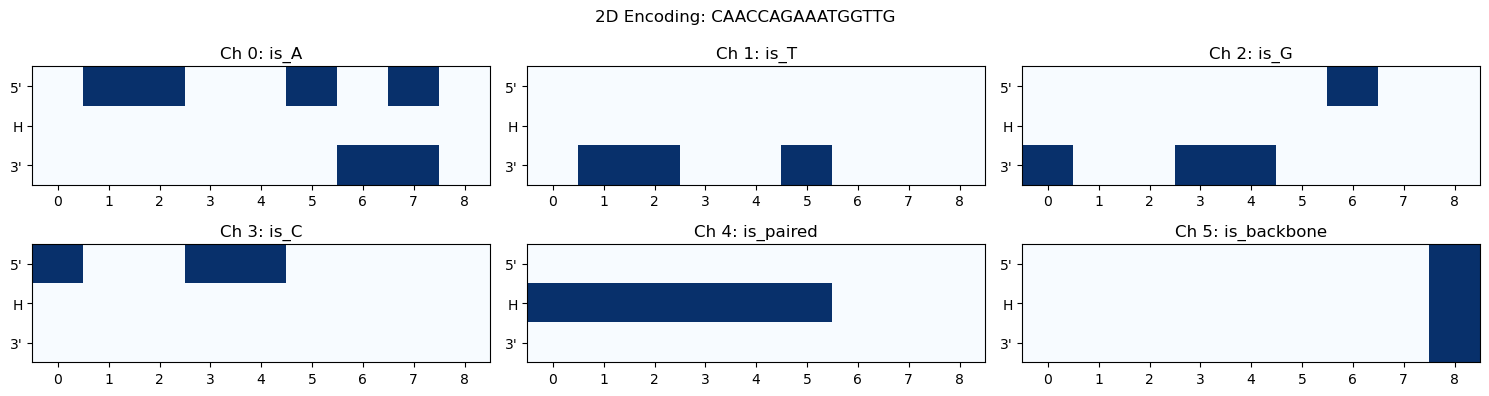

Sequence:  CAACCAGAAATGGTTG
Structure: ((((((....))))))

Folded ladder (width=9):
  5' strand:  [C  A  A  C  C  A  G  A  ~]
    H-bond :  [|  |  |  |  |  |        ~]
  3' strand:  [G  T  T  G  G  T  A  A  ~]


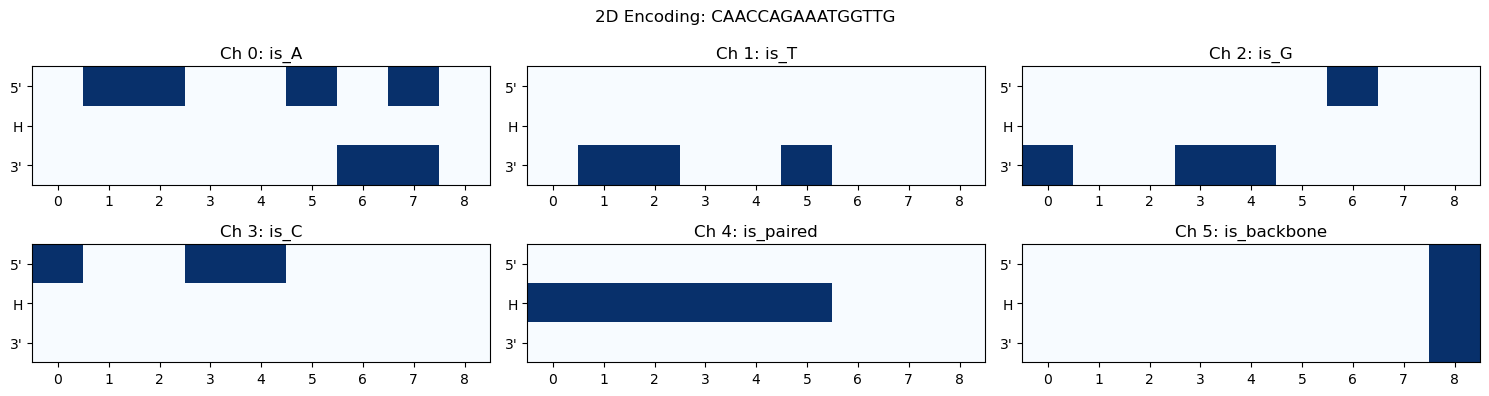

In [7]:
# ---- Visualize the 2D encoding for a sample ----

def visualize_2d_encoding(seq, struct, stats):
    """Show the integer-view and channel-view of the 2D encoding."""
    sample_row = pd.Series({'RefSeq': seq, 'TargetStruct': struct, 'dH': -30, 'Tm': 40})
    x, _ = encode_row_2d(sample_row, stats)
    arr = x.numpy()    # (6, 3, 13)
    
    # Reconstruct integer view (like user's original scheme)
    n_stem = struct.count('(')
    n_loop = struct.count('.')
    half_loop = n_loop // 2
    has_middle = (n_loop % 2 == 1)
    fold_len = n_stem + half_loop
    width = fold_len + 1  # +1 for backbone column
    
    # Build integer grid for display
    int_map = {0: 'A', 1: 'T', 2: 'G', 3: 'C'}
    grid = np.zeros((3, width), dtype=object)
    
    for col in range(fold_len):
        # Top row: find which nucleotide channel is active
        for ch in range(4):
            if arr[ch, 0, col] > 0:
                grid[0, col] = int_map[ch]
            if arr[ch, 2, col] > 0:
                grid[2, col] = int_map[ch]
        # H-bond
        grid[1, col] = '|' if arr[4, 1, col] > 0 else ' '
    
    # Backbone column
    grid[0, fold_len] = '~'
    grid[1, fold_len] = '~' 
    grid[2, fold_len] = '~'
    if has_middle:
        for ch in range(4):
            if arr[ch, 1, fold_len] > 0:
                grid[1, fold_len] = int_map[ch]
    
    print(f"Sequence:  {seq}")
    print(f"Structure: {struct}")
    print(f"\nFolded ladder (width={width}):")
    labels = ["5' strand", "  H-bond ", "3' strand"]
    for r in range(3):
        row_str = '  '.join(str(grid[r, c]) for c in range(width))
        print(f"  {labels[r]}:  [{row_str}]")
    
    # Show channel heatmaps
    ch_names = ['is_A', 'is_T', 'is_G', 'is_C', 'is_paired', 'is_backbone']
    fig, axes = plt.subplots(2, 3, figsize=(15, 4))
    for i, (ax, name) in enumerate(zip(axes.flat, ch_names)):
        im = ax.imshow(arr[i, :, :width], cmap='Blues', vmin=0, vmax=1, aspect='auto')
        ax.set_title(f'Ch {i}: {name}')
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(["5'", 'H', "3'"])
    plt.suptitle(f'2D Encoding: {seq}', fontsize=12)
    plt.tight_layout()
    plt.show()


# Visualize with the example from the markdown
visualize_2d_encoding('CAACCAGAAATGGTTG', '((((((....)))))) ', stats)

# Also show a real sample from the dataset
real_sample = df[df['dataset'] == 'arr'].iloc[0]
visualize_2d_encoding(real_sample['RefSeq'], real_sample['TargetStruct'], stats)

## Dataset & DataLoaders

In [8]:
# ---- 2D CNN Dataset ----

class NNN2DDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset that encodes each sequence as a (6, 3, max_width) 2D image.
    """
    def __init__(self, dataframe, stats, max_width=MAX_WIDTH):
        self.df = dataframe.copy()
        self.stats = stats
        self.max_width = max_width
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return encode_row_2d(row, self.stats, self.max_width)


# Split data: train on arr, validate on arr
train_ids = split_dict['train_ind']
val_ids = split_dict['val_ind']
test_ids = split_dict['test_ind']

arr_df = df[df['dataset'] == 'arr']

train_2d_df = arr_df[arr_df.index.isin(train_ids)]
val_2d_df   = arr_df[arr_df.index.isin(val_ids)]
test_2d_df  = arr_df[arr_df.index.isin(test_ids)]

train_2d_ds = NNN2DDataset(train_2d_df, stats)
val_2d_ds   = NNN2DDataset(val_2d_df, stats)
test_2d_ds  = NNN2DDataset(test_2d_df, stats)

BATCH_SIZE = 256

train_2d_loader = torch.utils.data.DataLoader(train_2d_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_2d_loader   = torch.utils.data.DataLoader(val_2d_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_2d_loader  = torch.utils.data.DataLoader(test_2d_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train: {len(train_2d_ds)}, Val: {len(val_2d_ds)}, Test: {len(test_2d_ds)}")
x_check, y_check = next(iter(train_2d_loader))
print(f"Batch shape: {x_check.shape}  (batch, 6 channels, 3 rows, {MAX_WIDTH} width)")

Train: 25025, Val: 1318, Test: 1387
Batch shape: torch.Size([256, 6, 3, 15])  (batch, 6 channels, 3 rows, 15 width)



## 2D CNN Model with Attention Pooling

The model uses **Conv2d** kernels of height 3 — each kernel spans all 3 rows (both strands + H-bond) simultaneously. This means every kernel directly "sees" which bases are paired and what's stacking on top.

- **Kernel (3,3):** captures a single stacking interaction (2 consecutive base pairs)
- **Kernel (3,5):** captures trinucleotide context (4 consecutive base pairs)
- **AttentionPool2d:** learns which positions matter most (vs. treating all equally)
- **MLP head:** maps to [dH, Tm] predictions

### Why Attention Pooling instead of GlobalAvgPool?

`GlobalAvgPool2d` averages over *all* spatial positions equally — padding zeros dilute real signal, and terminal base pairs (which fray) get the same weight as stable interior pairs.

**Attention pooling** learns per-position importance weights:

$$\alpha_i = \text{softmax}\left(\mathbf{v}^\top \tanh(\mathbf{W} \mathbf{h}_i)\right), \quad \mathbf{z} = \sum_i \alpha_i \cdot \mathbf{h}_i$$

This lets the model:
- Downweight padding positions (learned masking)
- Focus on interior stacking (most thermodynamically important)
- Differentiate backbone turn column vs. duplex gap


In [7]:

# ---- Attention Pooling Module for 2D feature maps ----

class AttentionPool2d(torch.nn.Module):
    """
    Learned attention pooling over spatial dimensions (H, W).
    
    Instead of AdaptiveAvgPool2d (equal weight everywhere),
    this learns per-position importance:
        score_i = v^T · tanh(W · h_i)     — scalar per spatial position
        α_i = softmax(score_i)             — importance weights (sum to 1)
        output = Σ α_i · h_i              — weighted aggregation
    
    Input:  (batch, C, H, W)
    Output: (batch, C)
    """
    def __init__(self, in_channels):
        super().__init__()
        self.attention = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, 64, kernel_size=1),   # W · h_i (pointwise)
            torch.nn.Tanh(),
            torch.nn.Conv2d(64, 1, kernel_size=1),             # v^T · (...) → scalar
        )
    
    def forward(self, x):
        # x: (batch, C, H, W)
        B, C, H, W = x.shape
        scores = self.attention(x)                    # (B, 1, H, W)
        scores_flat = scores.view(B, 1, -1)           # (B, 1, H*W)
        weights = torch.softmax(scores_flat, dim=-1)  # (B, 1, H*W) — normalized
        
        x_flat = x.view(B, C, -1)                    # (B, C, H*W)
        out = (x_flat * weights).sum(dim=-1)          # (B, C)
        return out


# ---- 2D CNN Model Definition with Attention Pooling ----

class DNA_2DCNN(torch.nn.Module):
    """
    2D CNN for DNA thermodynamic prediction using the folded ladder encoding.
    Input:  (batch, 6, 3, max_width)  — 6 channels, height=3, width=W
    Output: (batch, 2) — normalized [dH, Tm]
    
    Uses learned attention pooling to weight positions by importance.
    """
    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()
        torch.manual_seed(12345)
        
        self.conv_block = torch.nn.Sequential(
            # Block 1: single base pair + immediate stacking
            torch.nn.Conv2d(in_channels, 64, kernel_size=(3, 3), padding=(1, 1)),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Dropout2d(dropout),
            
            # Block 2: dinucleotide stacking context
            torch.nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout2d(dropout),
            
            # Block 3: wider context (5-nt stacking window)
            torch.nn.Conv2d(128, 128, kernel_size=(3, 5), padding=(1, 2)),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout2d(dropout),
        )
        
        # Attention pooling: (batch, 128, 3, W) → (batch, 128)
        self.attn_pool = AttentionPool2d(128)
        
        # MLP prediction head
        self.head = torch.nn.Sequential(
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = self.conv_block(x)          # (B, 128, 3, W)
        x = self.attn_pool(x)           # (B, 128) — attention-weighted
        x = self.head(x)                # (B, 2)
        return x


model_2d = DNA_2DCNN().to(device)
n_params = sum(p.numel() for p in model_2d.parameters())
print(f"2D CNN has {n_params:,} parameters")
print(model_2d)


2D CNN has 340,611 parameters
DNA_2DCNN(
  (conv_block): Sequential(
    (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(128, 128, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.2, inplace=False)
  )
  (attn_pool): AttentionPool2d(
    (attention): Sequential(
      (0): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): Tanh()
      (2): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (head): Sequential(
    (0): Linear(in_featur

## Training

In [10]:
# ---- wandb init ----
CONFIG_2D = dict(
    n_epoch=200,
    learning_rate=0.001,
    batch_size=BATCH_SIZE,
    dropout=0.2,
    architecture='2D_CNN_FoldedLadder',
    encoding='one_hot_6ch_3x13',
    dataset='NNN_v2_arr'
)

METHOD_NAME = '2DCNN'
ARTIFACT_ROOT = Path('MyExperiments') / METHOD_NAME
MODEL_ROOT = ARTIFACT_ROOT / 'models'
WANDB_ROOT = ARTIFACT_ROOT / 'wandb'
for folder in (MODEL_ROOT, WANDB_ROOT):
    folder.mkdir(parents=True, exist_ok=True)

RUN_NAME = f"{METHOD_NAME}_{datetime.now():%Y%m%d_%H%M%S}"
run_2d = wandb.init(project='NNN_GNN', config=CONFIG_2D, reinit=True, name=RUN_NAME, dir=str(WANDB_ROOT))
print(f'wandb run: {run_2d.name}')
RUN_DIR = Path(run_2d.dir)



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/anant/.netrc.
wandb: Currently logged in as: apati087 (apati087-university-of-california-riverside) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb run: 2DCNN_20260302_015850


In [11]:
# ---- Training loop ----

@torch.no_grad()
def compute_rmse_2d(model, loader):
    """Compute RMSE on normalized predictions."""
    model.eval()
    total_se = 0.0
    n = 0
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        total_se += float(((pred - y_batch.to(device)) ** 2).sum())
        n += y_batch.shape[0]
    return np.sqrt(total_se / n)


criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model_2d.parameters(), lr=CONFIG_2D['learning_rate'])
history = {'epoch': [], 'train_rmse': [], 'val_rmse': []}

LOG_EVERY = 10

for epoch in range(CONFIG_2D['n_epoch']):
    model_2d.train()
    
    for x_batch, y_batch in train_2d_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        pred = model_2d(x_batch)
        loss = criterion(pred, y_batch)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
    if epoch % LOG_EVERY == 0:
        train_rmse = compute_rmse_2d(model_2d, train_2d_loader)
        val_rmse = compute_rmse_2d(model_2d, val_2d_loader)
        
        history['epoch'].append(epoch)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)
        
        wandb.log({'train_rmse': train_rmse, 'val_rmse': val_rmse}, step=epoch)
        print(f"Epoch {epoch:03d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

print('\n2D CNN Training Done!!')

Epoch 000 | Train RMSE: 0.1846 | Val RMSE: 0.1874
Epoch 010 | Train RMSE: 0.1056 | Val RMSE: 0.1080
Epoch 020 | Train RMSE: 0.0898 | Val RMSE: 0.0942
Epoch 030 | Train RMSE: 0.0848 | Val RMSE: 0.0914
Epoch 040 | Train RMSE: 0.0741 | Val RMSE: 0.0823
Epoch 050 | Train RMSE: 0.0693 | Val RMSE: 0.0786
Epoch 060 | Train RMSE: 0.0662 | Val RMSE: 0.0774
Epoch 070 | Train RMSE: 0.0658 | Val RMSE: 0.0771
Epoch 080 | Train RMSE: 0.0611 | Val RMSE: 0.0751
Epoch 090 | Train RMSE: 0.0588 | Val RMSE: 0.0754
Epoch 100 | Train RMSE: 0.0559 | Val RMSE: 0.0735
Epoch 110 | Train RMSE: 0.0563 | Val RMSE: 0.0758
Epoch 120 | Train RMSE: 0.0540 | Val RMSE: 0.0748
Epoch 130 | Train RMSE: 0.0539 | Val RMSE: 0.0765
Epoch 140 | Train RMSE: 0.0528 | Val RMSE: 0.0757
Epoch 150 | Train RMSE: 0.0501 | Val RMSE: 0.0745
Epoch 160 | Train RMSE: 0.0500 | Val RMSE: 0.0748
Epoch 170 | Train RMSE: 0.0488 | Val RMSE: 0.0751
Epoch 180 | Train RMSE: 0.0482 | Val RMSE: 0.0753
Epoch 190 | Train RMSE: 0.0475 | Val RMSE: 0.0752


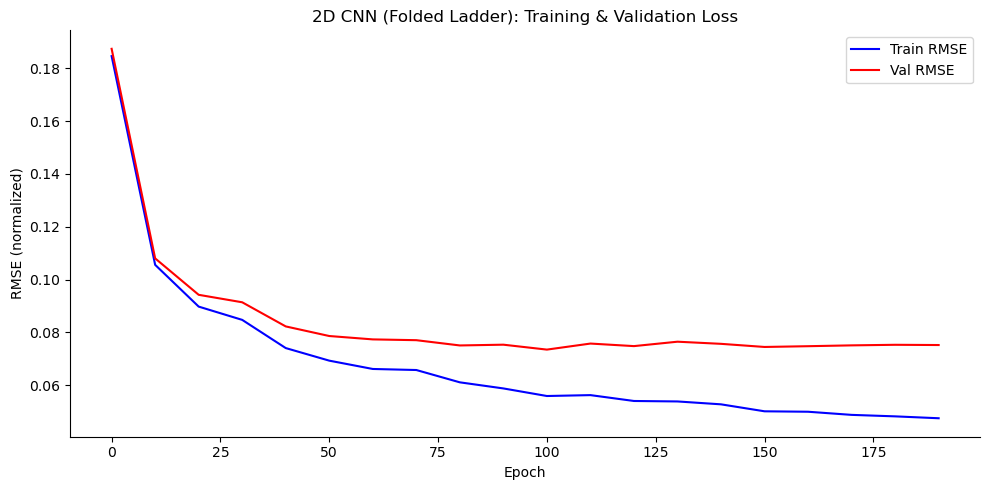

In [12]:
# ---- Loss Curves ----
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(history['epoch'], history['train_rmse'], label='Train RMSE', color='blue')
ax.plot(history['epoch'], history['val_rmse'], label='Val RMSE', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (normalized)')
ax.set_title('2D CNN (Folded Ladder): Training & Validation Loss')
ax.legend()
sns.despine()
plt.tight_layout()
wandb.log({'loss_curves': wandb.Image(fig)})
plt.show()

## Evaluation — Unnormalized Metrics

Compare against:
- **Paper GNN:** dH MAE=3.13, Tm MAE=1.80, dG₃₇ MAE=0.18
- **1D CNN:** dH MAE=3.02, Tm MAE=2.10, dG₃₇ MAE=0.20

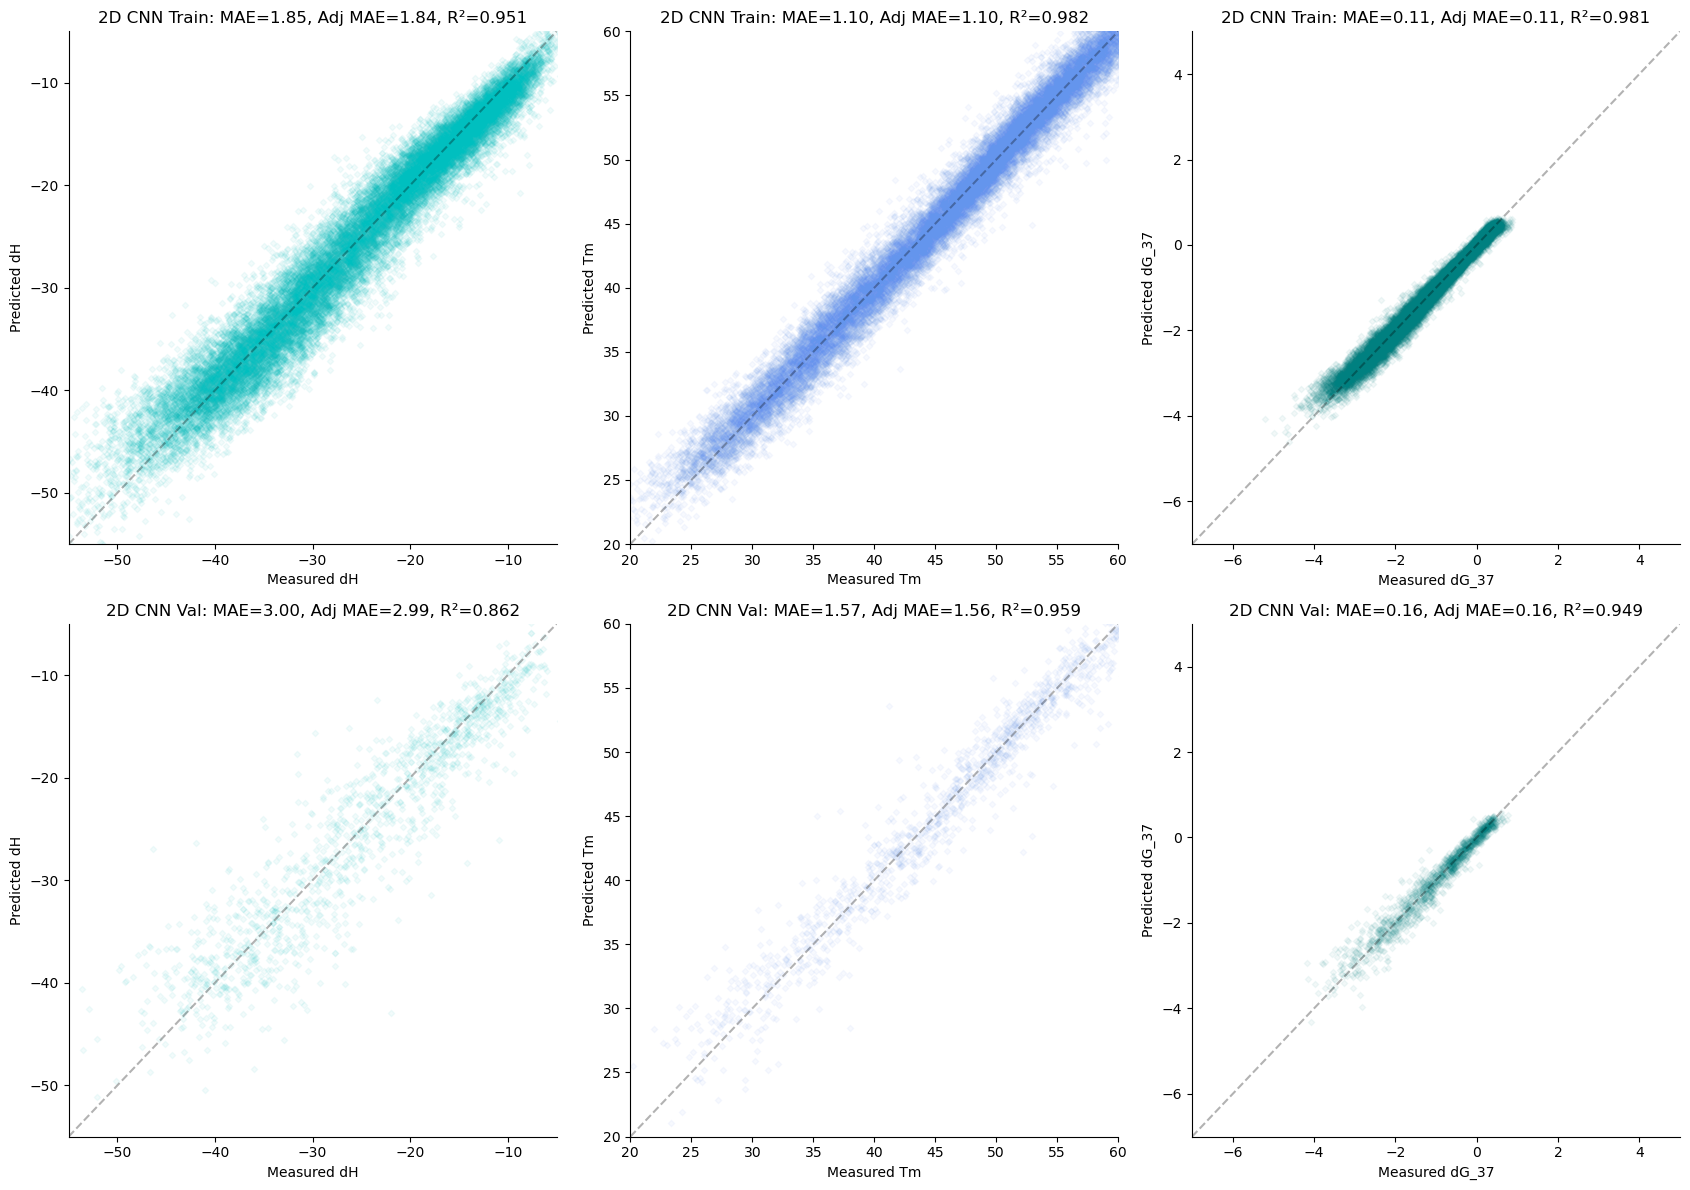


        2D CNN (Folded Ladder) — Validation Results         
Metric            MAE    Adj MAE     RMSE       R²     Bias
------------------------------------------------------------
dH             3.0004     2.9932   4.0957   0.8621  -0.1973
Tm             1.5654     1.5633   2.1869   0.9591  -0.1233
dG_37          0.1650     0.1649   0.2344   0.9485   0.0101

               Comparison (Val MAE)               
Model                      dH       Tm    dG_37
--------------------------------------------------
Paper GNN                3.13     1.80     0.18
1D CNN                   3.02     2.10     0.20
2D CNN (yours)           3.00     1.57     0.16


train_rmse,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_rmse,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_rmse,0.04751
val_rmse,0.07523


In [13]:
# ---- Get predictions in original scale ----

@torch.no_grad()
def get_predictions_2d(model, loader, stats):
    """Run 2D CNN model and return truth/pred arrays in original scale."""
    model.eval()
    y_all, pred_all = [], []
    
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        y_all.append(y_batch.numpy())
        pred_all.append(pred.cpu().numpy())
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize
    y[:, 0]    = unnormalize(y[:, 0],    stats['dH_min'], stats['dH_max'])
    y[:, 1]    = unnormalize(y[:, 1],    stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return y, pred


def plot_scatter(y, pred, ax, param_name, title, color, lim):
    """Plot measured vs predicted scatter with MAE, Adjusted MAE, R²."""
    mask = ~np.isnan(y)
    y, pred = y[mask], pred[mask]
    
    rmse = np.sqrt(np.mean((y - pred)**2))
    mae = np.mean(np.abs(y - pred))
    r2 = r2_score(y, pred)
    
    bias = np.mean(pred) - np.mean(y)
    pred_adj = pred - bias
    mae_adj = np.mean(np.abs(y - pred_adj))
    
    ax.scatter(y, pred, c=color, marker='D', alpha=0.05, s=10)
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'Measured {param_name}')
    ax.set_ylabel(f'Predicted {param_name}')
    ax.set_title(f'{title}: MAE={mae:.2f}, Adj MAE={mae_adj:.2f}, R²={r2:.3f}')
    return dict(rmse=rmse, mae=mae, mae_adj=mae_adj, r2=r2, bias=bias)


# Get predictions
train_y, train_pred = get_predictions_2d(model_2d, train_2d_loader, stats)
val_y, val_pred     = get_predictions_2d(model_2d, val_2d_loader, stats)

# ---- Scatter plots ----
fig, axes = plt.subplots(2, 3, figsize=(17, 12))

# Train
plot_scatter(train_y[:,0], train_pred[:,0], axes[0,0], 'dH', '2D CNN Train', 'c', [-55,-5])
plot_scatter(train_y[:,1], train_pred[:,1], axes[0,1], 'Tm', '2D CNN Train', 'cornflowerblue', [20,60])
train_dG = calc_dG37(train_y[:,0], train_y[:,1])
train_dG_pred = calc_dG37(train_pred[:,0], train_pred[:,1])
plot_scatter(train_dG, train_dG_pred, axes[0,2], 'dG_37', '2D CNN Train', 'teal', [-7,5])

# Validation
dH_m = plot_scatter(val_y[:,0], val_pred[:,0], axes[1,0], 'dH', '2D CNN Val', 'c', [-55,-5])
Tm_m = plot_scatter(val_y[:,1], val_pred[:,1], axes[1,1], 'Tm', '2D CNN Val', 'cornflowerblue', [20,60])
val_dG = calc_dG37(val_y[:,0], val_y[:,1])
val_dG_pred = calc_dG37(val_pred[:,0], val_pred[:,1])
dG_m = plot_scatter(val_dG, val_dG_pred, axes[1,2], 'dG_37', '2D CNN Val', 'teal', [-7,5])

sns.despine()
plt.tight_layout()
wandb.log({'results': wandb.Image(fig)})
plt.show()

# ---- Metrics table ----
print(f'\n{"="*60}')
print(f'{"2D CNN (Folded Ladder) — Validation Results":^60}')
print(f'{"="*60}')
print(f'{"Metric":<12} {"MAE":>8} {"Adj MAE":>10} {"RMSE":>8} {"R²":>8} {"Bias":>8}')
print(f'{"-"*60}')
for name, m in [('dH', dH_m), ('Tm', Tm_m), ('dG_37', dG_m)]:
    print(f'{name:<12} {m["mae"]:>8.4f} {m["mae_adj"]:>10.4f} {m["rmse"]:>8.4f} {m["r2"]:>8.4f} {m["bias"]:>8.4f}')
print(f'{"="*60}')

# ---- Comparison table ----
print(f'\n{"="*50}')
print(f'{"Comparison (Val MAE)":^50}')
print(f'{"="*50}')
print(f'{"Model":<20} {"dH":>8} {"Tm":>8} {"dG_37":>8}')
print(f'{"-"*50}')
print(f'{"Paper GNN":<20} {"3.13":>8} {"1.80":>8} {"0.18":>8}')
print(f'{"1D CNN":<20} {"3.02":>8} {"2.10":>8} {"0.20":>8}')
print(f'{"2D CNN (yours)":<20} {dH_m["mae"]:>8.2f} {Tm_m["mae"]:>8.2f} {dG_m["mae"]:>8.2f}')
print(f'{"="*50}')

wandb.finish()

In [14]:
import pandas as pd
df = pd.read_csv('data/models/raw/combined_dataset.csv', index_col='SEQID')
for ds in ['lit_uv', 'ov', 'uv']:
    sub = df[df['dataset']==ds]
    print(f'{ds}: {len(sub)} records, dH NaN: {sub.dH.isna().sum()}, Tm NaN: {sub.Tm.isna().sum()}')
    # Check max sequence length (for duplexes, both strands concatenated)
    max_len = 0
    for seq in sub['RefSeq']:
        if '[' in str(seq):
            strands = eval(seq)
            max_len = max(max_len, max(len(s) for s in strands))
        else:
            max_len = max(max_len, len(seq))
    print(f'  Max strand length: {max_len}')
    # Check has + in structure
    has_plus = sub['TargetStruct'].str.contains('\+', na=False).sum()
    print(f'  Duplexes (has +): {has_plus}')

lit_uv: 348 records, dH NaN: 348, Tm NaN: 0
  Max strand length: 30
  Duplexes (has +): 348
ov: 2775 records, dH NaN: 2775, Tm NaN: 0
  Max strand length: 19
  Duplexes (has +): 2775
uv: 19 records, dH NaN: 0, Tm NaN: 0
  Max strand length: 16
  Duplexes (has +): 0


            2D CNN — Cross-Dataset Tm Evaluation            
Dataset           N      MAE    Adj MAE     RMSE       R²
------------------------------------------------------------


ov             2775    13.00       2.34    13.32   -7.731

Note: lit_uv and ov are duplexes (never seen in training).
arr validation Tm MAE for reference: 1.57


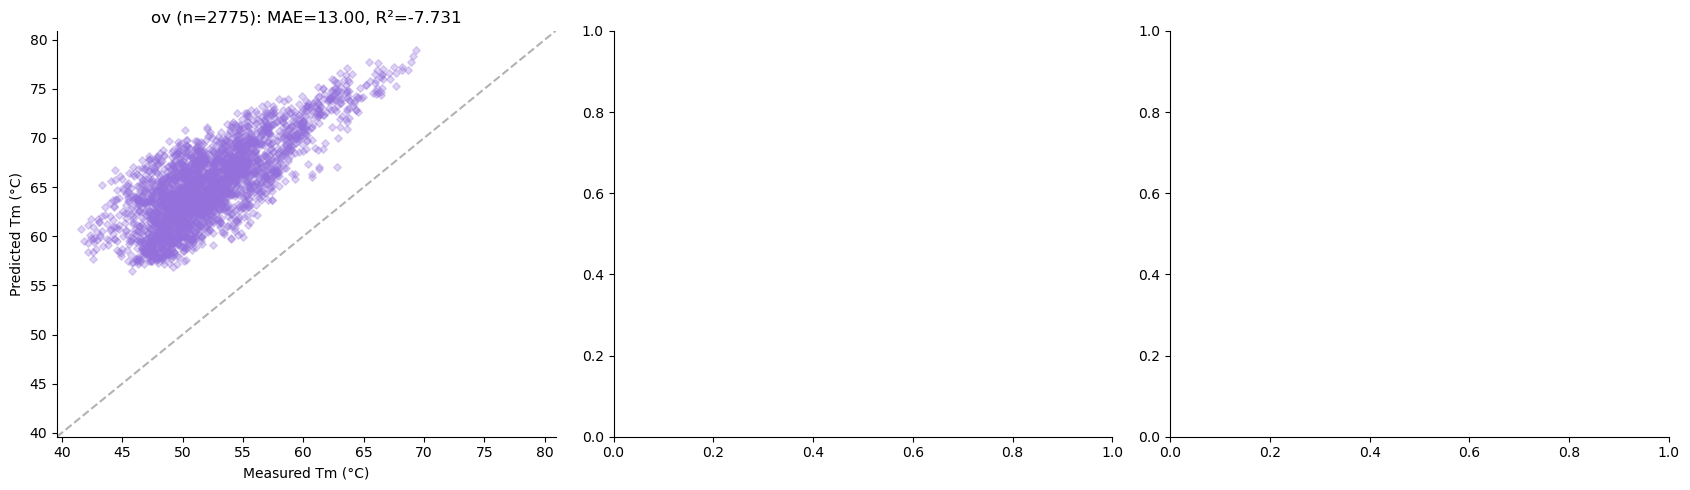

In [15]:
# ---- Evaluate on lit_uv and ov datasets (Tm only, dH is NaN) ----
# Conv2d + AdaptiveAvgPool2d is fully convolutional — works at any width.
# We just need max_width >= 30 to fit the longest lit_uv strand.

EVAL_MAX_WIDTH = 30  # covers lit_uv (30 nt) and ov (19 nt)

@torch.no_grad()
def predict_tm_for_dataset(model, dataset_name, df, stats, max_width=EVAL_MAX_WIDTH):
    """
    Predict Tm for a specific dataset subset. Returns (true_Tm, pred_Tm).
    Uses the 2D folded encoding with wider padding for longer duplexes.
    """
    model.eval()
    sub = df[df['dataset'] == dataset_name].dropna(subset=['Tm']).copy()
    
    if len(sub) == 0:
        return None, None
    
    ds = NNN2DDataset(sub, stats, max_width=max_width)
    loader = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=False)
    
    y_all, pred_all = [], []
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        y_all.append(y_batch.numpy())
        pred_all.append(pred.cpu().numpy())
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize Tm (column 1)
    true_Tm = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred_Tm = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return true_Tm, pred_Tm


print(f'{"="*60}')
print(f'{"2D CNN — Cross-Dataset Tm Evaluation":^60}')
print(f'{"="*60}')
print(f'{"Dataset":<12} {"N":>6} {"MAE":>8} {"Adj MAE":>10} {"RMSE":>8} {"R²":>8}')
print(f'{"-"*60}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = {'lit_uv': 'coral', 'ov': 'mediumpurple', 'uv': 'seagreen'}

for i, ds_name in enumerate(['ov']):
    true_Tm, pred_Tm = predict_tm_for_dataset(model_2d, ds_name, df, stats)
    
    if true_Tm is None:
        print(f'{ds_name:<12} {"—":>6} {"N/A":>8}')
        continue
    
    mae = np.mean(np.abs(true_Tm - pred_Tm))
    bias = np.mean(pred_Tm) - np.mean(true_Tm)
    mae_adj = np.mean(np.abs(true_Tm - (pred_Tm - bias)))
    rmse = np.sqrt(np.mean((true_Tm - pred_Tm)**2))
    r2 = r2_score(true_Tm, pred_Tm)
    
    print(f'{ds_name:<12} {len(true_Tm):>6} {mae:>8.2f} {mae_adj:>10.2f} {rmse:>8.2f} {r2:>8.3f}')
    
    # Scatter plot
    ax = axes[i]
    ax.scatter(true_Tm, pred_Tm, c=colors[ds_name], marker='D', alpha=0.3, s=15)
    lim = [min(true_Tm.min(), pred_Tm.min()) - 2, max(true_Tm.max(), pred_Tm.max()) + 2]
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Measured Tm (°C)')
    ax.set_ylabel('Predicted Tm (°C)')
    ax.set_title(f'{ds_name} (n={len(true_Tm)}): MAE={mae:.2f}, R²={r2:.3f}')

print(f'{"="*60}')
print(f'\nNote: lit_uv and ov are duplexes (never seen in training).')
print(f'arr validation Tm MAE for reference: {Tm_m["mae"]:.2f}')

sns.despine()
plt.tight_layout()
plt.show()

In [16]:
wandb.finish()
model_dir = MODEL_ROOT / RUN_NAME
model_dir.mkdir(parents=True, exist_ok=True)
torch.save(model_2d.state_dict(), model_dir / 'model.pt')
current_wandb_dir = RUN_DIR
if current_wandb_dir.exists():
    target_wandb_dir = WANDB_ROOT / RUN_NAME
    if target_wandb_dir.exists():
        shutil.rmtree(target_wandb_dir)
    shutil.move(str(current_wandb_dir), str(target_wandb_dir))
    print(f"Saved wandb logs to {target_wandb_dir}")
print(f"Saved model to {model_dir / 'model.pt'}")


Saved wandb logs to MyExperiments/2DCNN/wandb/2DCNN_20260302_015850
Saved model to MyExperiments/2DCNN/models/2DCNN_20260302_015850/model.pt


# Evaluation on External Datasets (to be completed)

In [8]:
import json
from glob import glob

# Create and load the 2D CNN model
cnn2d_model = DNA_2DCNN().to(device)
cnn2d_model_dir = sorted(glob('MyExperiments/2DCNN/models/*/'))[-1]
cnn2d_model.load_state_dict(torch.load(os.path.join(cnn2d_model_dir, 'model.pt'), map_location=device))
cnn2d_model.eval()
print(f"Loaded 2D CNN model from: {cnn2d_model_dir}")

# Load external datasets and combined training data for stats
combined_df = pd.read_csv('data/models/raw/combined_dataset.csv', index_col='SEQID')
with open('data/models/raw/combined_data_split.json', 'r') as f:
    split_dict = json.load(f)

# Compute normalization stats from training data
train_df = combined_df.loc[combined_df.index.isin(split_dict['train_ind'])]
stats = {
    'dH_min': float(train_df['dH'].min()),
    'dH_max': float(train_df['dH'].max()),
    'Tm_min': float(train_df['Tm'].min()),
    'Tm_max': float(train_df['Tm'].max()),
}

def calc_dG37(dH, Tm):
    """Calculate dG at 37°C from dH (kcal/mol) and Tm (°C)."""
    return dH * (1 - (273.15 + 37) / (273.15 + Tm))

def compute_metrics(y_true, y_pred):
    """Compute MAE, RMSE, R², Bias. Handle NaN values."""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return {'MAE': np.nan, 'RMSE': np.nan, 'R2': np.nan, 'Bias': np.nan}
    y_t = y_true[mask]
    y_p = y_pred[mask]
    mae = np.mean(np.abs(y_t - y_p))
    rmse = np.sqrt(np.mean((y_t - y_p) ** 2))
    r2 = r2_score(y_t, y_p) if len(y_t) > 1 else np.nan
    bias = np.mean(y_p - y_t)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias}

# Evaluate 2D CNN on external datasets
print("\n" + "="*80)
print("2D CNN MODEL EVALUATION ON EXTERNAL DATASETS")

Loaded 2D CNN model from: MyExperiments/2DCNN/models/2DCNN_20260302_015850/

2D CNN MODEL EVALUATION ON EXTERNAL DATASETS


In [ ]:
external_datasets = ['ov', 'uv', 'lit_uv', 'arr']
cnn2d_results = {}

for ext_ds in external_datasets:
    print(f"\n>>> Evaluating on {ext_ds.upper()} dataset...")
    
    # Load external dataset
    ext_df = combined_df[combined_df['dataset'] == ext_ds].copy()
    



    if len(ext_df) == 0:
        print(f"   No data for {ext_ds}")
        continue
    
    # If it's 'arr' (training data), use combined val+test split
    if ext_ds == 'arr':
        val_ids = split_dict['val_ind']
        test_ids = split_dict['test_ind']
        combined_ids = val_ids + test_ids
        ext_df = ext_df.loc[ext_df.index.isin(combined_ids)]
    
    print(f"   Size: {len(ext_df)}")
    
    # Encode sequences
    x_list = []
    y_list = []
    for idx, row in ext_df.iterrows():
        try:
            x_2dcnn, y = encode_row_2d(row, stats, MAX_WIDTH)
            x_list.append(x_2dcnn)
            y_list.append(y)
        except Exception as e:
            print(f"   Skipped {idx}: {e}")
            continue
    
    if len(x_list) == 0:
        print(f"   Failed to encode any sequences for {ext_ds}")
        continue
    
    x_tensor = torch.stack(x_list)
    y_tensor = torch.stack(y_list)
    
    # Create DataLoader
    dataset = torch.utils.data.TensorDataset(x_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)
    
    # Run inference
    y_pred_all = []
    y_true_all = []
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            out = cnn2d_model(batch_x)
            y_pred_all.append(out.cpu().numpy())
            y_true_all.append(batch_y.numpy())
    
    y_pred_all = np.concatenate(y_pred_all, axis=0)
    y_true_all = np.concatenate(y_true_all, axis=0)
    
    # Unnormalize
    dH_true = y_true_all[:, 0] * (stats['dH_max'] - stats['dH_min']) + stats['dH_min']
    dH_pred = y_pred_all[:, 0] * (stats['dH_max'] - stats['dH_min']) + stats['dH_min']
    Tm_true = y_true_all[:, 1] * (stats['Tm_max'] - stats['Tm_min']) + stats['Tm_min']
    Tm_pred = y_pred_all[:, 1] * (stats['Tm_max'] - stats['Tm_min']) + stats['Tm_min']
    
    # For datasets without dH (ov, lit_uv), mask dH metrics
    if ext_ds in ['ov', 'lit_uv']:
        dH_true[:] = np.nan
    
    # Compute dG37
    dG37_true = np.array([calc_dG37(dH_true[i], Tm_true[i]) if not np.isnan(dH_true[i]) else np.nan 
                          for i in range(len(dH_true))])
    dG37_pred = np.array([calc_dG37(dH_pred[i], Tm_pred[i]) if not np.isnan(dH_pred[i]) else np.nan 
                          for i in range(len(dH_pred))])
    
    # Compute metrics
    cnn2d_results[ext_ds] = {
        'dH': compute_metrics(dH_true, dH_pred),
        'Tm': compute_metrics(Tm_true, Tm_pred),
        'dG37': compute_metrics(dG37_true, dG37_pred),
        'n_samples': len(ext_df),
    }
    
    print(f"   dH metrics:  MAE={cnn2d_results[ext_ds]['dH']['MAE']:.4f}, R²={cnn2d_results[ext_ds]['dH']['R2']:.4f}")
    print(f"   Tm metrics:  MAE={cnn2d_results[ext_ds]['Tm']['MAE']:.4f}, R²={cnn2d_results[ext_ds]['Tm']['R2']:.4f}")
    print(f"   dG37 metrics: MAE={cnn2d_results[ext_ds]['dG37']['MAE']:.4f}, R²={cnn2d_results[ext_ds]['dG37']['R2']:.4f}")

print("\n" + "="*80)
print("2D CNN Evaluation Complete")
print("="*80)

# Print summary table
print(f"\n{'Dataset':<12} {'dH MAE':>8} {'Tm MAE':>8} {'dG37 MAE':>10}")
print("-" * 40)
for ds in external_datasets:
    if ds in cnn2d_results:
        dH_mae = cnn2d_results[ds]['dH']['MAE']
        Tm_mae = cnn2d_results[ds]['Tm']['MAE']
        dG_mae = cnn2d_results[ds]['dG37']['MAE']
        print(f"{ds:<12} {dH_mae:>8.4f} {Tm_mae:>8.4f} {dG_mae:>10.4f}")


>>> Evaluating on OV dataset...
   Size: 2775
   dH metrics:  MAE=nan, R²=nan
   Tm metrics:  MAE=11.9479, R²=-6.6691
   dG37 metrics: MAE=nan, R²=nan

>>> Evaluating on UV dataset...
   Size: 19
   dH metrics:  MAE=8.7795, R²=-1.2931
   Tm metrics:  MAE=7.6316, R²=0.1994
   dG37 metrics: MAE=0.9766, R²=0.1518

>>> Evaluating on LIT_UV dataset...
   Size: 348
   dH metrics:  MAE=nan, R²=nan
   Tm metrics:  MAE=7.7505, R²=0.1099
   dG37 metrics: MAE=nan, R²=nan

>>> Evaluating on ARR dataset...
   Size: 2705
   dH metrics:  MAE=2.9425, R²=0.8673
   Tm metrics:  MAE=1.6115, R²=0.9551
   dG37 metrics: MAE=0.1636, R²=0.9492

2D CNN Evaluation Complete

Dataset        dH MAE   Tm MAE   dG37 MAE
----------------------------------------
ov                nan  11.9479        nan
uv             8.7795   7.6316     0.9766
lit_uv            nan   7.7505        nan
arr            2.9425   1.6115     0.1636
